Comenzaremos con la preparación del dataset previa a la implementación del modelo. El primer paso será la importación de las librerías necesarias y el dataset objetivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = 'CTC_original.csv' #Lorca_original.csv para el de Lorca, Murcia
                             #CTC_original.csv para el de Santander, Cantabria
data = pd.read_csv(dataset, sep=";")

data.head() #Mostramos primeras filas

,datetime,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
0,24/01/2025 13:12,65,17.6,24.1,100,55.0,0.0,29.9
1,24/01/2025 13:17,70,17.6,22.5,105,54.0,0.0,29.9
2,24/01/2025 13:22,76,17.7,33.8,111,54.0,0.0,29.9
3,24/01/2025 13:27,82,17.7,17.7,114,53.0,0.0,29.9
4,24/01/2025 13:32,78,17.7,27.4,105,53.0,0.0,29.9


- datetime: Fecha
- Power_gen: Potencia generada en kilovatios
- temperature: Temperatura en grados celsius
- windSpeed: Velocidad del viento en kilómetros/hora
- solarRad: Irradiancia solar en vatios/metro cuadrado
- humedad: Porcentaje de humedad
- rain: Lluvia en milímetros
- pressure: Presión en hectopascales

Visualizamos información referente al dataset.

In [2]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58557 entries, 0 to 58556
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     58557 non-null  object 
 1   Power_gen    58557 non-null  int64  
 2   temperature  58556 non-null  float64
 3   windSpeed    58556 non-null  float64
 4   solarRad     58557 non-null  int64  
 5   humedad      58556 non-null  float64
 6   rain         58556 non-null  float64
 7   pressure     58556 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 3.6+ MB


Como necesitaremos las columnas en valores numéricos, debemos pasar las de tipo objeto a tipo float antes de continuar.

In [3]:
cols = [c for c in data.columns if c != "datetime"]

#Antes de pasar a float, limpiamos los datos (eliminando las unidades y dejando solo el valor numérico)
for c in cols:
    s = data[c].astype(str)
    s = s.str.replace(r"[^0-9\.,-]", "", regex=True)
    s = s.str.replace(",", ".", regex=False)
    data[c] = pd.to_numeric(s, errors="coerce")

data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58557 entries, 0 to 58556
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     58557 non-null  object 
 1   Power_gen    58557 non-null  int64  
 2   temperature  58556 non-null  float64
 3   windSpeed    58556 non-null  float64
 4   solarRad     58557 non-null  int64  
 5   humedad      58556 non-null  float64
 6   rain         58556 non-null  float64
 7   pressure     58556 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 3.6+ MB


Ahora que tenemos los datos limpios y en formato numérico, mostramos la descripción estadística para observar valores como la media, máximo, ...

In [4]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,58557.000000,58556.000000,58556.000000,58557.000000,58556.000000,58556.000000,58556.000000
mean,140.065577,23.985625,10.111159,301.990368,78.895160,41.056011,30.104104
std,222.298932,115.637599,27.089252,2131.832891,16.549642,143.277903,0.581917
min,0.000000,4.440000,0.000000,0.000000,29.000000,0.000000,0.000000
25%,0.000000,12.900000,3.220000,0.000000,71.000000,0.000000,30.000000
50%,0.000000,16.400000,6.440000,18.000000,81.000000,0.000000,30.100000
75%,191.000000,20.000000,12.900000,253.000000,88.000000,2.200000,30.300000
max,780.000000,1803.000000,410.000000,32767.000000,255.000000,800.000000,30.700000


Observamos que hay valores claramente erróneos que alteran los resultados (temperature=1803, windSpeed=410,...). Posteriormente los trataremos.

Histograma:

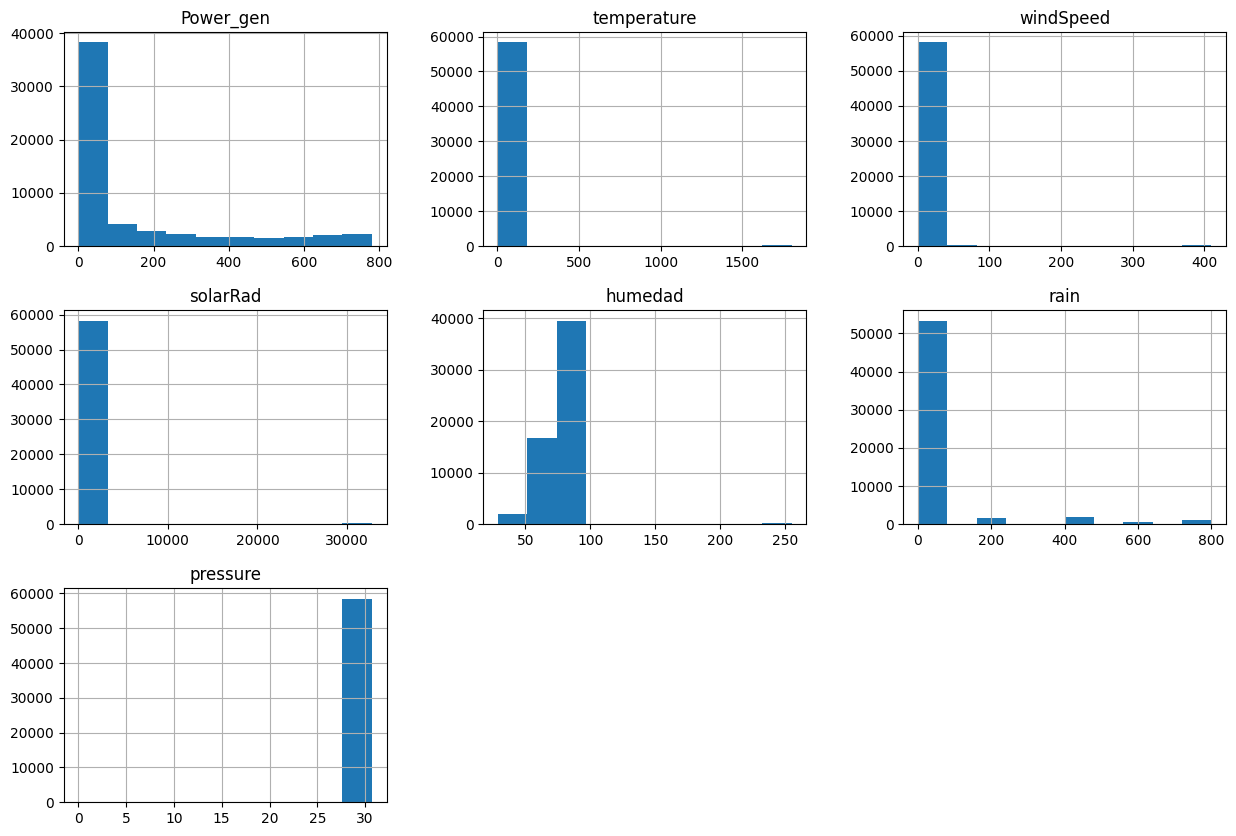

In [5]:
histograma = data.hist(figsize=(15, 10))

Podemos observar que los valores de todas las variables se concentran mayoritariamente en una parte del histograma, con valores extraordinarios muy alejados de esta. Power_gen y pressure son la excepción, ya que si presentan histogramas razonables.

Con violinplots se observa claramente:

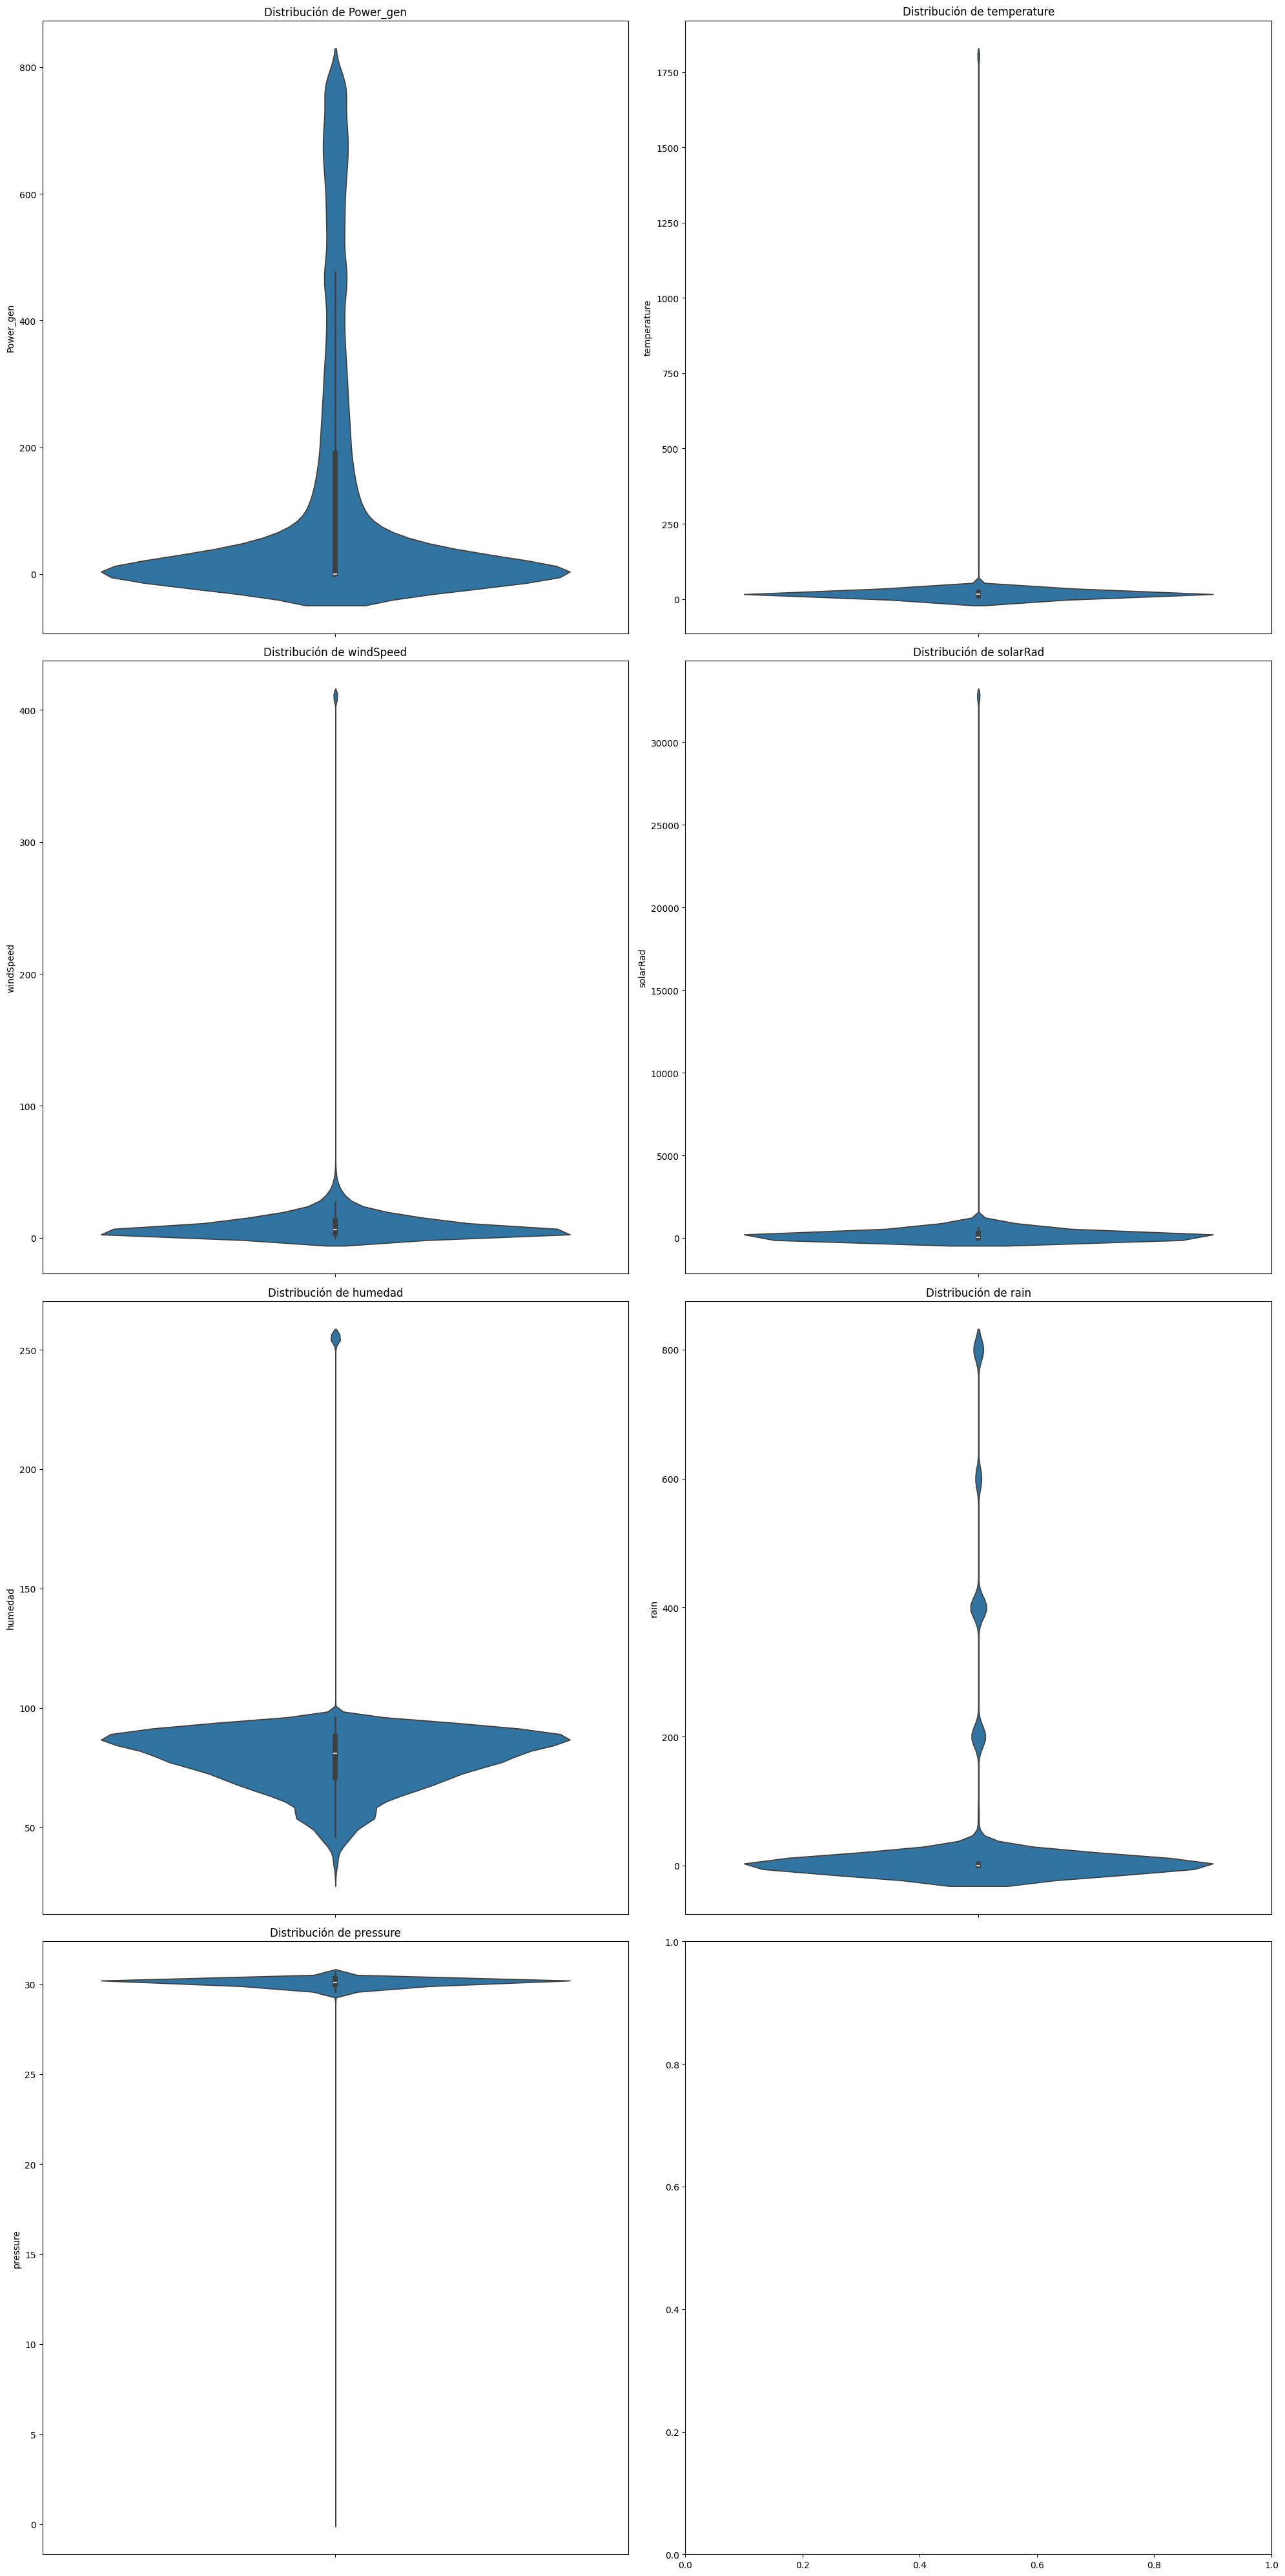

In [6]:
#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Como los outliers alteran enormemente el resultado del modelo, hemos de eliminarlos del dataset.

Para calcular los outliers, hemos de calcular primero el IQR de cada variable. Esto es la diferencia entre el percentil 75 y el percentil 25, de forma que el valor resultante representa el rango en el que se encuentra el 50% central de los datos. Normalmente, se consideran outliers los valores por debajo de (percentil 25 - 1.5 * IQR) o por encima de (percentil 75 + 1.5 * IQR).

In [7]:
outlier_cols = data.select_dtypes(include=[np.number]).columns.drop('Power_gen')

P25 = data[outlier_cols].quantile(0.25) #Percentil 25
P75 = data[outlier_cols].quantile(0.75) #Percentil 75
IQR = P75 - P25 #Interquartile Range


#Identificar outliers
outliers = ((data[outlier_cols] < (P25 - 1.5 * IQR)) | (data[outlier_cols] > (P75 + 1.5 * IQR)))
print(outliers.sum())

temperature     386
windSpeed      1895
solarRad       5449
humedad         976
rain           9636
pressure        828
dtype: int64


Con los outliers detectados, procedemos a eliminarlos del dataset.

In [8]:
data = data.loc[~outliers.any(axis=1)].reset_index(drop=True)

Volvemos a mostrar los histogramas y violinplots para ver el resultado

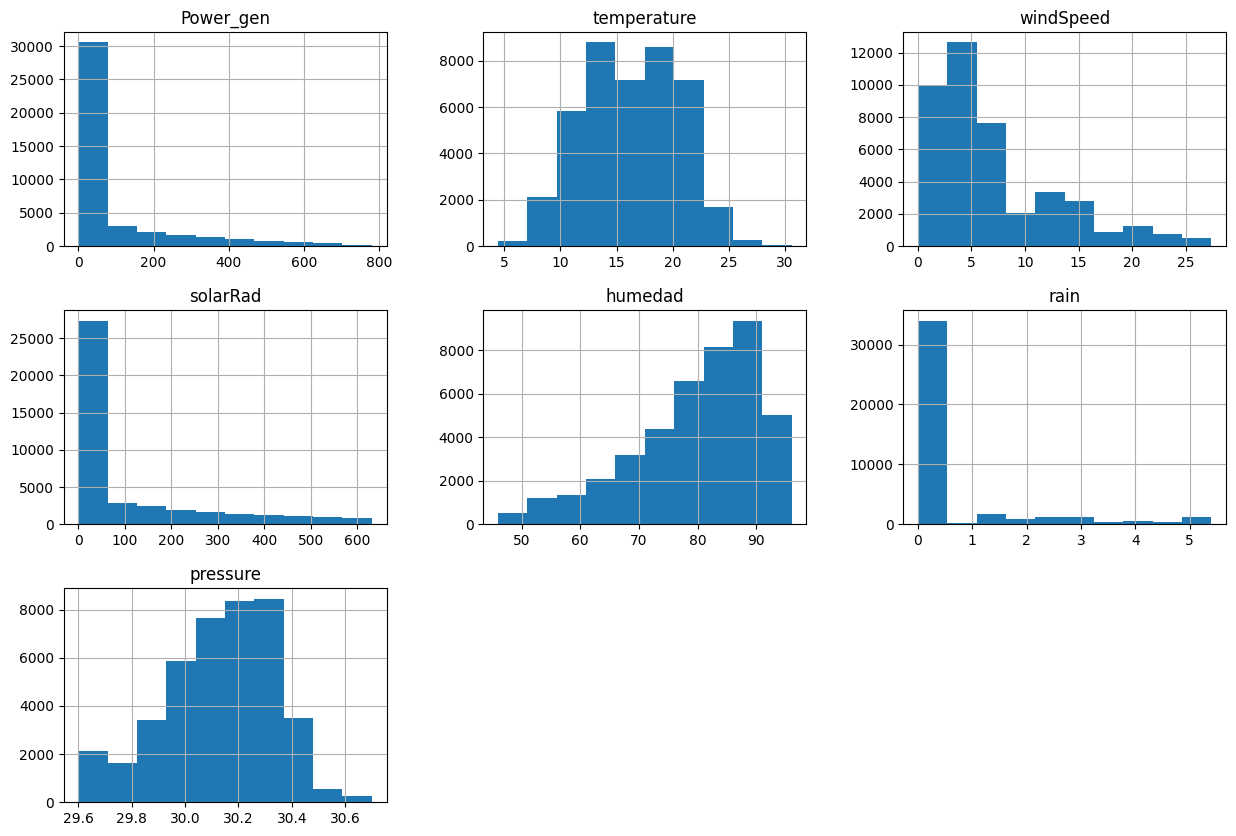

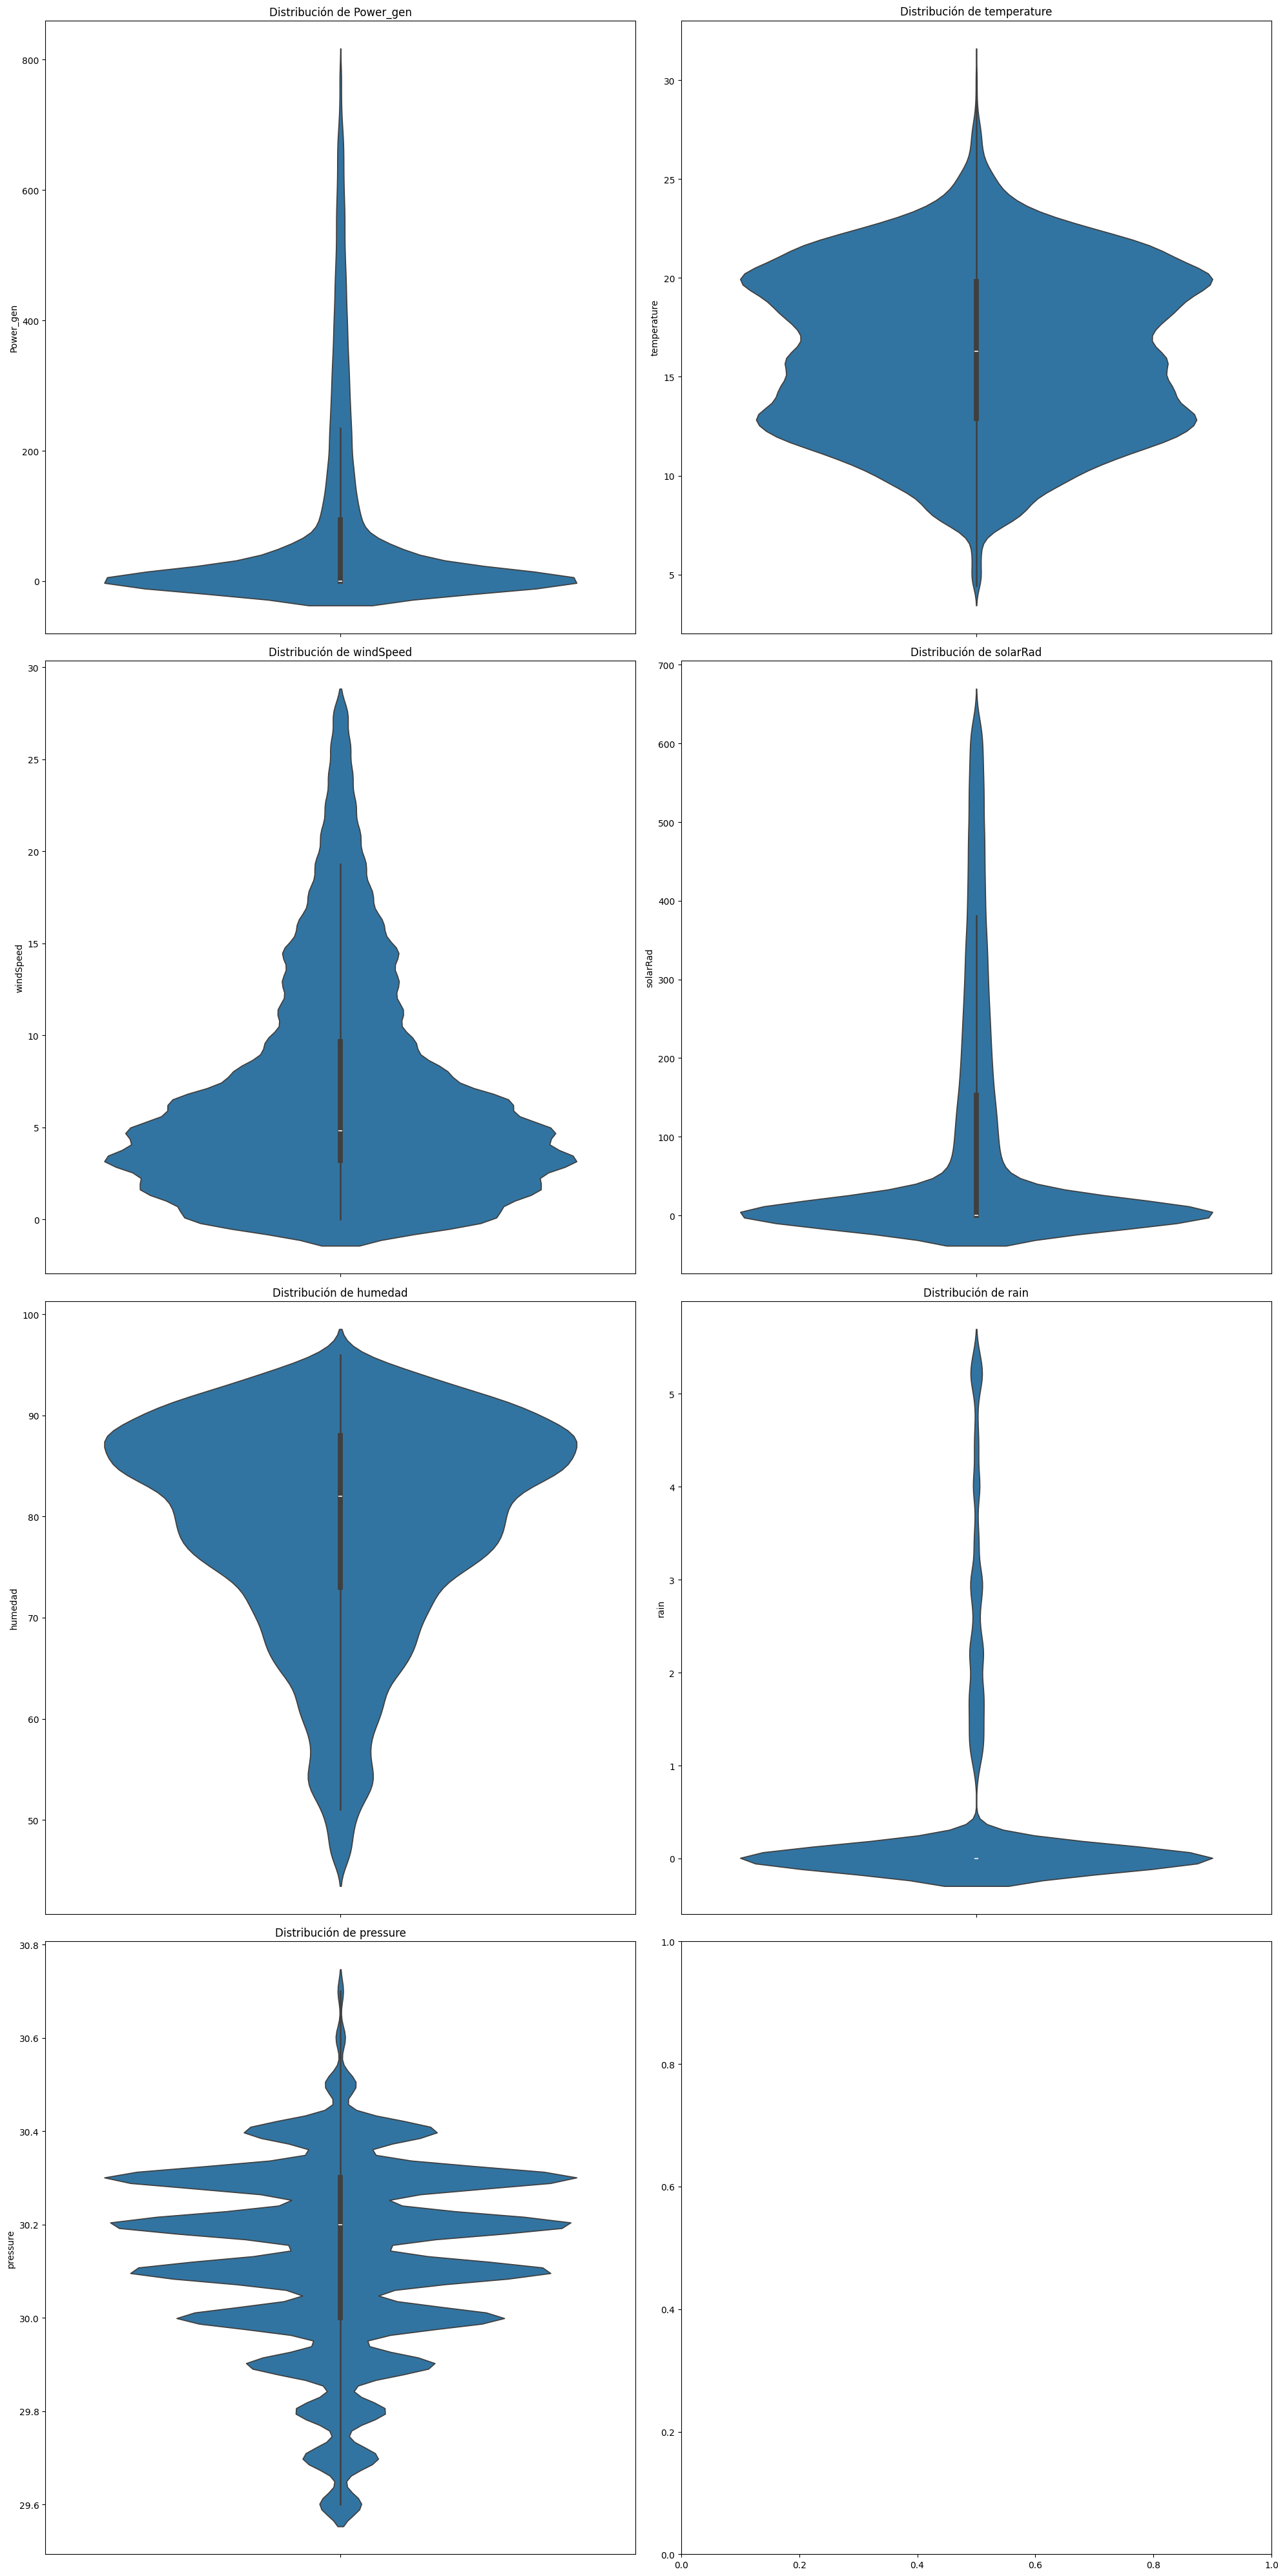

In [9]:
histograma = data.hist(figsize=(15, 10))

#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Consultamos la nueva información y descripción analítica.

In [10]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41822 entries, 0 to 41821
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     41822 non-null  object 
 1   Power_gen    41822 non-null  int64  
 2   temperature  41821 non-null  float64
 3   windSpeed    41821 non-null  float64
 4   solarRad     41822 non-null  int64  
 5   humedad      41821 non-null  float64
 6   rain         41821 non-null  float64
 7   pressure     41821 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 2.6+ MB


In [11]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,41822.000000,41821.000000,41821.000000,41822.000000,41821.000000,41821.000000,41821.000000
mean,86.631103,16.318428,6.869420,101.447061,79.292532,0.525492,30.130212
std,156.514780,4.222477,5.991205,162.071354,10.709026,1.244369,0.196403
min,0.000000,4.440000,0.000000,0.000000,46.000000,0.000000,29.600000
25%,0.000000,12.900000,3.220000,0.000000,73.000000,0.000000,30.000000
50%,0.000000,16.300000,4.830000,0.000000,82.000000,0.000000,30.200000
75%,94.000000,19.800000,9.660000,153.000000,88.000000,0.000000,30.300000
max,780.000000,30.600000,27.400000,631.000000,96.000000,5.400000,30.700000


Observamos que los valores imposibles se han eliminado, dejando como resultado los valores reales.

Eliminamos filas con NaN

In [12]:
data = data.dropna()

Información y descripción del dataset final

In [13]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 41821 entries, 0 to 41821
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     41821 non-null  object 
 1   Power_gen    41821 non-null  int64  
 2   temperature  41821 non-null  float64
 3   windSpeed    41821 non-null  float64
 4   solarRad     41821 non-null  int64  
 5   humedad      41821 non-null  float64
 6   rain         41821 non-null  float64
 7   pressure     41821 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 2.9+ MB


In [14]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,41821.000000,41821.000000,41821.000000,41821.000000,41821.000000,41821.000000,41821.000000
mean,86.632242,16.318428,6.869420,101.447096,79.292532,0.525492,30.130212
std,156.516478,4.222477,5.991205,162.073291,10.709026,1.244369,0.196403
min,0.000000,4.440000,0.000000,0.000000,46.000000,0.000000,29.600000
25%,0.000000,12.900000,3.220000,0.000000,73.000000,0.000000,30.000000
50%,0.000000,16.300000,4.830000,0.000000,82.000000,0.000000,30.200000
75%,94.000000,19.800000,9.660000,153.000000,88.000000,0.000000,30.300000
max,780.000000,30.600000,27.400000,631.000000,96.000000,5.400000,30.700000


Para ver el grado de correlación entre las variables, usaremos un MinMaxScaler y un heatmap.

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = data.copy()
data_scaled[numeric_cols.columns] = scaler.fit_transform(data_scaled[numeric_cols.columns])
data_scaled.drop(columns=["datetime"], inplace=True) #Eliminamos las columnas no numéricas, datetime en este caso

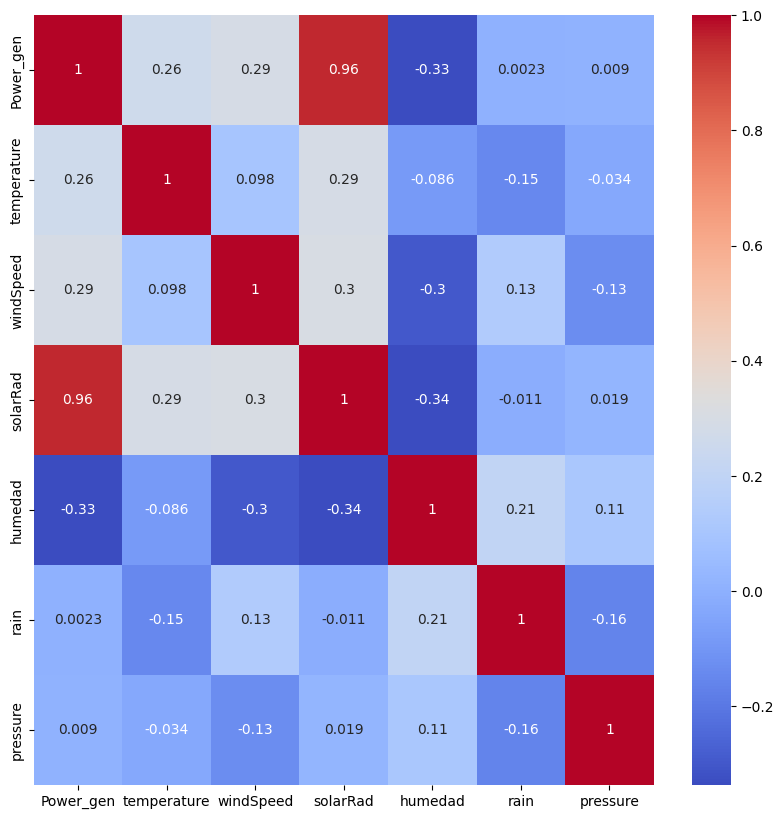

In [16]:
corr_df = data_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Guardamos en un CSV nuevo

In [17]:
if dataset == 'Lorca_original.csv':
    data = data.loc[data['Power_gen'].shift() != data['Power_gen']]#eliminamos filas con valores repetidos en power_gen de forma local,
                                                                         #ya que la medicion de power_gen no es sincrona con las demas variables
    data.to_csv("Lorca_processed.csv", sep=";", index=False)
elif dataset == 'CTC_original.csv':
    data.to_csv("CTC_processed.csv", sep=";", index=False)